# Differentially methylated regions: statistics (Fig 2M, S12)

Part of the **[Fig. 2 chapter](fig2.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `f'{indir}L1color.tsv'`  ·  _metadata: color_
- `f'{REF_ROOT}/hg38/gencode/v30/gencode.v30.annotation.gene.flat.tsv.gz'`  ·  _ref: gencode_
- `f'{indir}scRNA/Teichmann2022/Myeloid.h5ad'`  ·  _scRNA/expr_
- `f'{outdir}{ct}_{mode}dmr_center.bed'`  ·  _DMR_
- `f'{outdir}tss_{mode}dmr_dist_{s}.hdf'`  ·  _DMR_
- `f'{indir}merged_allc/subtype1k.mcds'`  ·  _sc/pseudobulk mC (allc)_
- `f'{indir}subtype_meta.tsv'`  ·  _metadata_
- `f'{outdir}subtype_dmr.mcds'`  ·  _mC matrix (mcds)_
- `f'{indir}merged_allc/subtype_globalCG.csv.gz'`  ·  _sc/pseudobulk mC (allc)_
- `f'{indir}DMR/majortype-subtype/{ct}_dmr'`  ·  _DMR_
- `f'{indir}DMR/majortype-subtype/{mt}_dmr'`  ·  _DMR_


In [ ]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [ ]:
import os
import numpy as np
import pandas as pd
from glob import glob
from scipy.sparse import csr_matrix
from scipy.stats import zscore
from concurrent.futures import ProcessPoolExecutor, as_completed

import anndata
from ALLCools.mcds import MCDS, RegionDS
from ALLCools.clustering import *
from ALLCools.plot import *

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'

import warnings
warnings.filterwarnings("ignore")


In [ ]:
indir = f'{ENTEX_ROOT}/'
outdir = f'{indir}analysis/DMR/'


In [ ]:
L1_meta = pd.read_csv(f'{indir}L1color.tsv', sep='\t', header=0, index_col=0)
# L1_meta = L1_meta.drop(['c35', 'c36'], axis=0)
L1_meta = L1_meta.drop(['c7'], axis=0)
L1_annot = L1_meta['L1_abbr'].to_dict()
L1_color = L1_meta['color'].to_dict()
L1_color.update({L1_annot[k]: L1_color[k] for k in L1_annot if k in L1_color})  # also key by name


In [ ]:
import cooler
chrom_size_path = f'{REF_ROOT}/hg38/fasta/hg38.main.chrom.sizes'
chrom_sizes = cooler.read_chromsizes(chrom_size_path, all_names=True)
chrom_sizes = chrom_sizes.iloc[:22]


In [ ]:
## write majortype DMR
ndms = 4
ngroup = 36
dmr_dir = f'{indir}DMR/majortype/{ngroup}groups'
out_dir = f'{indir}analysis/DMR/overlap_atac/majortype_{ngroup}groups/'
dmr_ds = RegionDS.open(dmr_dir, region_dim='dmr')
dmr = dmr_ds[['dmr_chrom', 'dmr_start', 'dmr_end', 'dmr_ndms']].to_pandas()
dmr[['dmr_start', 'dmr_end', 'dmr_ndms']] = dmr[['dmr_start', 'dmr_end', 'dmr_ndms']].astype(int)
seldmr = (dmr['dmr_ndms']>=ndms) & (dmr['dmr_chrom'].isin(chrom_sizes.index))
dmr_ds = dmr_ds.sel({'dmr':dmr.index[seldmr]})
dmr = dmr.loc[seldmr]
dmr_state = dmr_ds['dmr_state'].to_pandas().T
seldmr = (dmr_state.drop(['c1','c2','c3','c9','c22','c35'], axis=1)==-1).sum(axis=1)>0
print(seldmr.sum(), seldmr.shape[0])
dmr = dmr.loc[seldmr]
dmr_tmp = dmr.reset_index()[['dmr_chrom', 'dmr_start', 'dmr_end', 'dmr', 'dmr_ndms']]
dmr_tmp.sort_values(by=['dmr_chrom', 'dmr_start']).to_csv(f'{indir}analysis/DMR/overlap_atac/majortype_36groups/majortype_dms4.bed',  sep='\t', header=False, index=False)


In [ ]:
from matplotlib_venn import venn2
colors = list(sns.color_palette('Blues', 3))


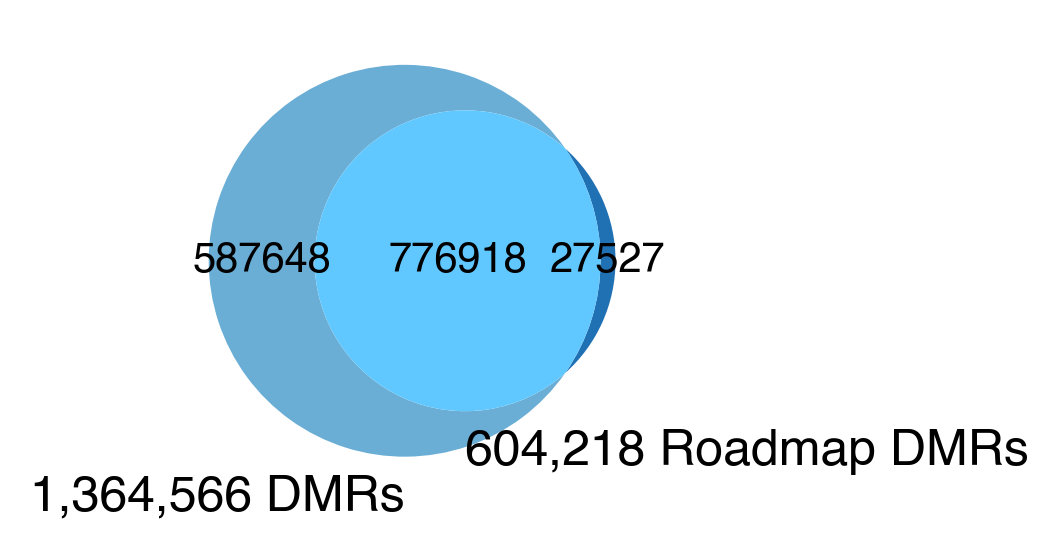

In [ ]:
fig, ax = plt.subplots(figsize=(4,2), dpi=300)
venn2(subsets=(1364566-776918, 604218-576691, 776918), 
      set_labels=('1,364,566 DMRs', '604,218 Roadmap DMRs'),
      alpha=1.0,
      set_colors=(colors[1], colors[2]), 
      ax=ax)
fig.savefig(f'{outdir}DMR_roadmapDMR_overlap_venn.pdf', transparent=True)


## subtype DMR

In [ ]:
import os

dmr_len = []
dmr_stats = []
for ct in L1_meta.index:
    dmr_file_path = f'{indir}DMR/majortype-subtype/{ct}_dmr/dmr.bed'
    if os.path.isfile(dmr_file_path):
        dmr = pd.read_csv(dmr_file_path, names=['chrom', 'start', 'end', 'dmr_id'], 
                          header=None, index_col=3, sep='\t')
        tmp = pd.DataFrame(dmr['end'] - dmr['start'], columns=['length'])
        tmp['L1'] = ct
        dmr_len.append(tmp)
        dmr_stats.append([ct, tmp.shape[0], tmp['length'].sum()])
    
dmr_len = pd.concat(dmr_len, axis=0)
dmr_stats = pd.DataFrame(dmr_stats, columns=['L1', '#DMR', 'length']).set_index('L1')


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(4, 3), dpi=300)
# ax.spines['bottom'].set_position('zero')
# ax.spines['right'].set_visible(False)
# ax.spines['top'].set_visible(False)
xticks = np.arange(dmr_stats.shape[0])
for i,xx in enumerate(['#DMR', 'length']):
    ax = axes[i]
    leg_order = dmr_stats.sort_values(xx).index[::-1]
    tmp = dmr_stats.loc[leg_order]
    ax.bar(x=np.arange(dmr_stats.shape[0]), height=tmp[xx], color=tmp.index.map(L1_color), width=0.8)
    ax.set_xticks(xticks)
    ax.set_xticklabels(tmp.index.map(L1_annot), fontsize=6, rotation=90)
    ax.set_yscale('log')
    ax.set_xlim([-1, dmr_stats.shape[0]])
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=6)
    
fig.tight_layout()


## merged DMR per majortype

In [ ]:
import os

dmr_len = []
dmr_stats = []
for ct in L1_meta.index:
    dmr_file_path = f'{indir}analysis/DMR/overlap_atac/majortype_36groups/{ct}_merged.bed'
    if os.path.isfile(dmr_file_path):
        dmr = pd.read_csv(dmr_file_path, names=['chrom', 'start', 'end', 'dmr_id'], 
                          header=None, index_col=3, sep='\t')
        if dmr.shape[0]>0:
            tmp = pd.DataFrame(dmr['end'] - dmr['start'], columns=['length'])
            tmp['L1'] = ct
            dmr_len.append(tmp)
            dmr_stats.append([ct, tmp.shape[0], tmp['length'].sum()])
    
dmr_len = pd.concat(dmr_len, axis=0)
dmr_stats = pd.DataFrame(dmr_stats, columns=['L1', '#DMR', 'length']).set_index('L1')


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(4, 3), dpi=300)
# ax.spines['bottom'].set_position('zero')
# ax.spines['right'].set_visible(False)
# ax.spines['top'].set_visible(False)
xticks = np.arange(dmr_stats.shape[0])
for i,xx in enumerate(['#DMR', 'length']):
    ax = axes[i]
    leg_order = dmr_stats.sort_values(xx).index[::-1]
    tmp = dmr_stats.loc[leg_order]
    ax.bar(x=np.arange(dmr_stats.shape[0]), height=tmp[xx], color=tmp.index.map(L1_color), width=0.8)
    ax.set_xticks(xticks)
    ax.set_xticklabels(tmp.index.map(L1_annot), fontsize=6, rotation=90)
    ax.set_yscale('log')
    ax.set_xlim([-1, dmr_stats.shape[0]])
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=6)
    
fig.tight_layout()


In [ ]:
outdir = f'{indir}analysis/DMR/dist/'

In [ ]:
gene_meta = pd.read_csv(f'{REF_ROOT}/hg38/gencode/v30/gencode.v30.annotation.gene.flat.tsv.gz', sep='\t', header=0)
gene_meta['gene_id_idx'] = gene_meta['gene_id'].str.split('.').str[0]
gene_meta = gene_meta.drop_duplicates(subset='gene_name')
gene_meta = gene_meta.loc[gene_meta['chrom'].isin(chrom_sizes.index)]

In [ ]:
gene_meta[['TSS','TES']] = gene_meta[['start','end']].copy()
selg = (gene_meta['strand']=='-')
gene_meta.loc[selg, ['TSS','TES']] = gene_meta.loc[selg, ['TES','TSS']].values


In [ ]:
gene_meta = gene_meta.set_index('gene_id_idx')

In [ ]:
gene_meta['slop_start'] = gene_meta['start'] - 1000000
gene_meta['slop_end'] = gene_meta['end'] + 1000000
gene_meta = gene_meta.loc[(gene_meta['slop_start']>=0) & (gene_meta['slop_end']<=gene_meta['chrom'].map(chrom_sizes))]
gene_meta.reset_index()[['chrom', 'slop_start', 'slop_end', 'gene_id_idx']].to_csv(f'{outdir}gene_slop1m.bed', sep='\t', header=False, index=False)


In [ ]:
adata = anndata.read_h5ad(f'{indir}scRNA/Teichmann2022/Myeloid.h5ad')
hcagene = adata.var.index[adata.var.index.isin(gene_meta.index)]


In [ ]:
for ct in L1_meta.index:
    # dmr_file_path = f'{indir}analysis/DMR/overlap_atac/majortype_36groups/{ct}_merged.bed'
    # dmr_file_path = f'{indir}DMR/majortype-subtype/{ct}_dmr/dmr.bed'
    dmr_file_path = f'{indir}analysis/DMR/overlap_atac/majortype_36groups/{ct}_dmr.bed'
    if os.path.isfile(dmr_file_path):
        try:
            dmr = pd.read_csv(dmr_file_path, sep='\t', header=None, index_col=None, usecols=(0,1,2))
        except pd.errors.EmptyDataError:
            print(ct)
            continue
        dmr.columns = ['chrom', 'start', 'end']
        dmr['center'] = (dmr['start'] + dmr['end']) // 2
        dmr.reset_index()[['chrom', 'center', 'center', 'index']].to_csv(f'{outdir}{ct}_majortypedmr_center.bed', sep='\t', header=False, index=False)
        

In [ ]:
for ct in L1_meta.index:
    for mode in ['', 'majortype', 'subtype']:
        file_path = f'{outdir}{ct}_{mode}dmr_gene_1m.txt'
        if os.path.isfile(file_path):
            try:
                e2g = pd.read_csv(file_path, sep='\t', header=None, index_col=None)
            except pd.errors.EmptyDataError:
                print(f'{ct} {mode} empty')
                continue
            e2g.columns = ['dmr', 'gene']
            dmr = pd.read_csv(f'{outdir}{ct}_{mode}dmr_center.bed', sep='\t', header=None, index_col=2, usecols=(0,1,3))
            dmr.columns = ['chrom','center']
            e2g['TSSdist'] = dmr.loc[e2g['dmr'], 'center'].values - gene_meta.loc[e2g['gene'], 'TSS'].values
            e2g['TESdist'] = dmr.loc[e2g['dmr'], 'center'].values - gene_meta.loc[e2g['gene'], 'TES'].values
            selg = (gene_meta.loc[e2g['gene'], 'strand']=='-')
            e2g.loc[selg.values, 'TSSdist'] = -e2g.loc[selg.values, 'TSSdist'].values
            e2g.loc[selg.values, 'TESdist'] = -e2g.loc[selg.values, 'TESdist'].values
            e2g.to_hdf(f'{outdir}{ct}_{mode}DMR_gene_dist.hdf', key='data')
    print(ct)
        

In [ ]:
def num2str(num):
    if num>=1e6:
        num_str = f'{int(num//1e6)}M'
    elif num>=1e3:
        num_str = f'{int(num//1e3)}k'
    else:
        num_str = f'{num}'
    return num_str


In [ ]:
slop = 100
for i,res in enumerate([10000, 1000, 100]):
    for mode in ['', 'majortype', 'subtype']:
        data = []
        for ct in L1_meta.index:
            file_path = f'{outdir}{ct}_{mode}DMR_gene_dist.hdf'
            if os.path.isfile(file_path):
                e2g = pd.read_hdf(file_path, key='data')
                tmp = e2g.loc[e2g['gene'].isin(hcagene) & (np.abs(e2g['TSSdist'])<=(slop*res))]
                dist_count = tmp.groupby(tmp['TSSdist']//res).count()['dmr'].sort_index()
                dist_count.name = ct
                data.append(dist_count)
                print(res, mode, ct)
        data = pd.concat(data, axis=1)
        s = num2str(slop*res)
        data.to_hdf(f'{outdir}tss_{mode}dmr_dist_{s}.hdf', key='data')
    

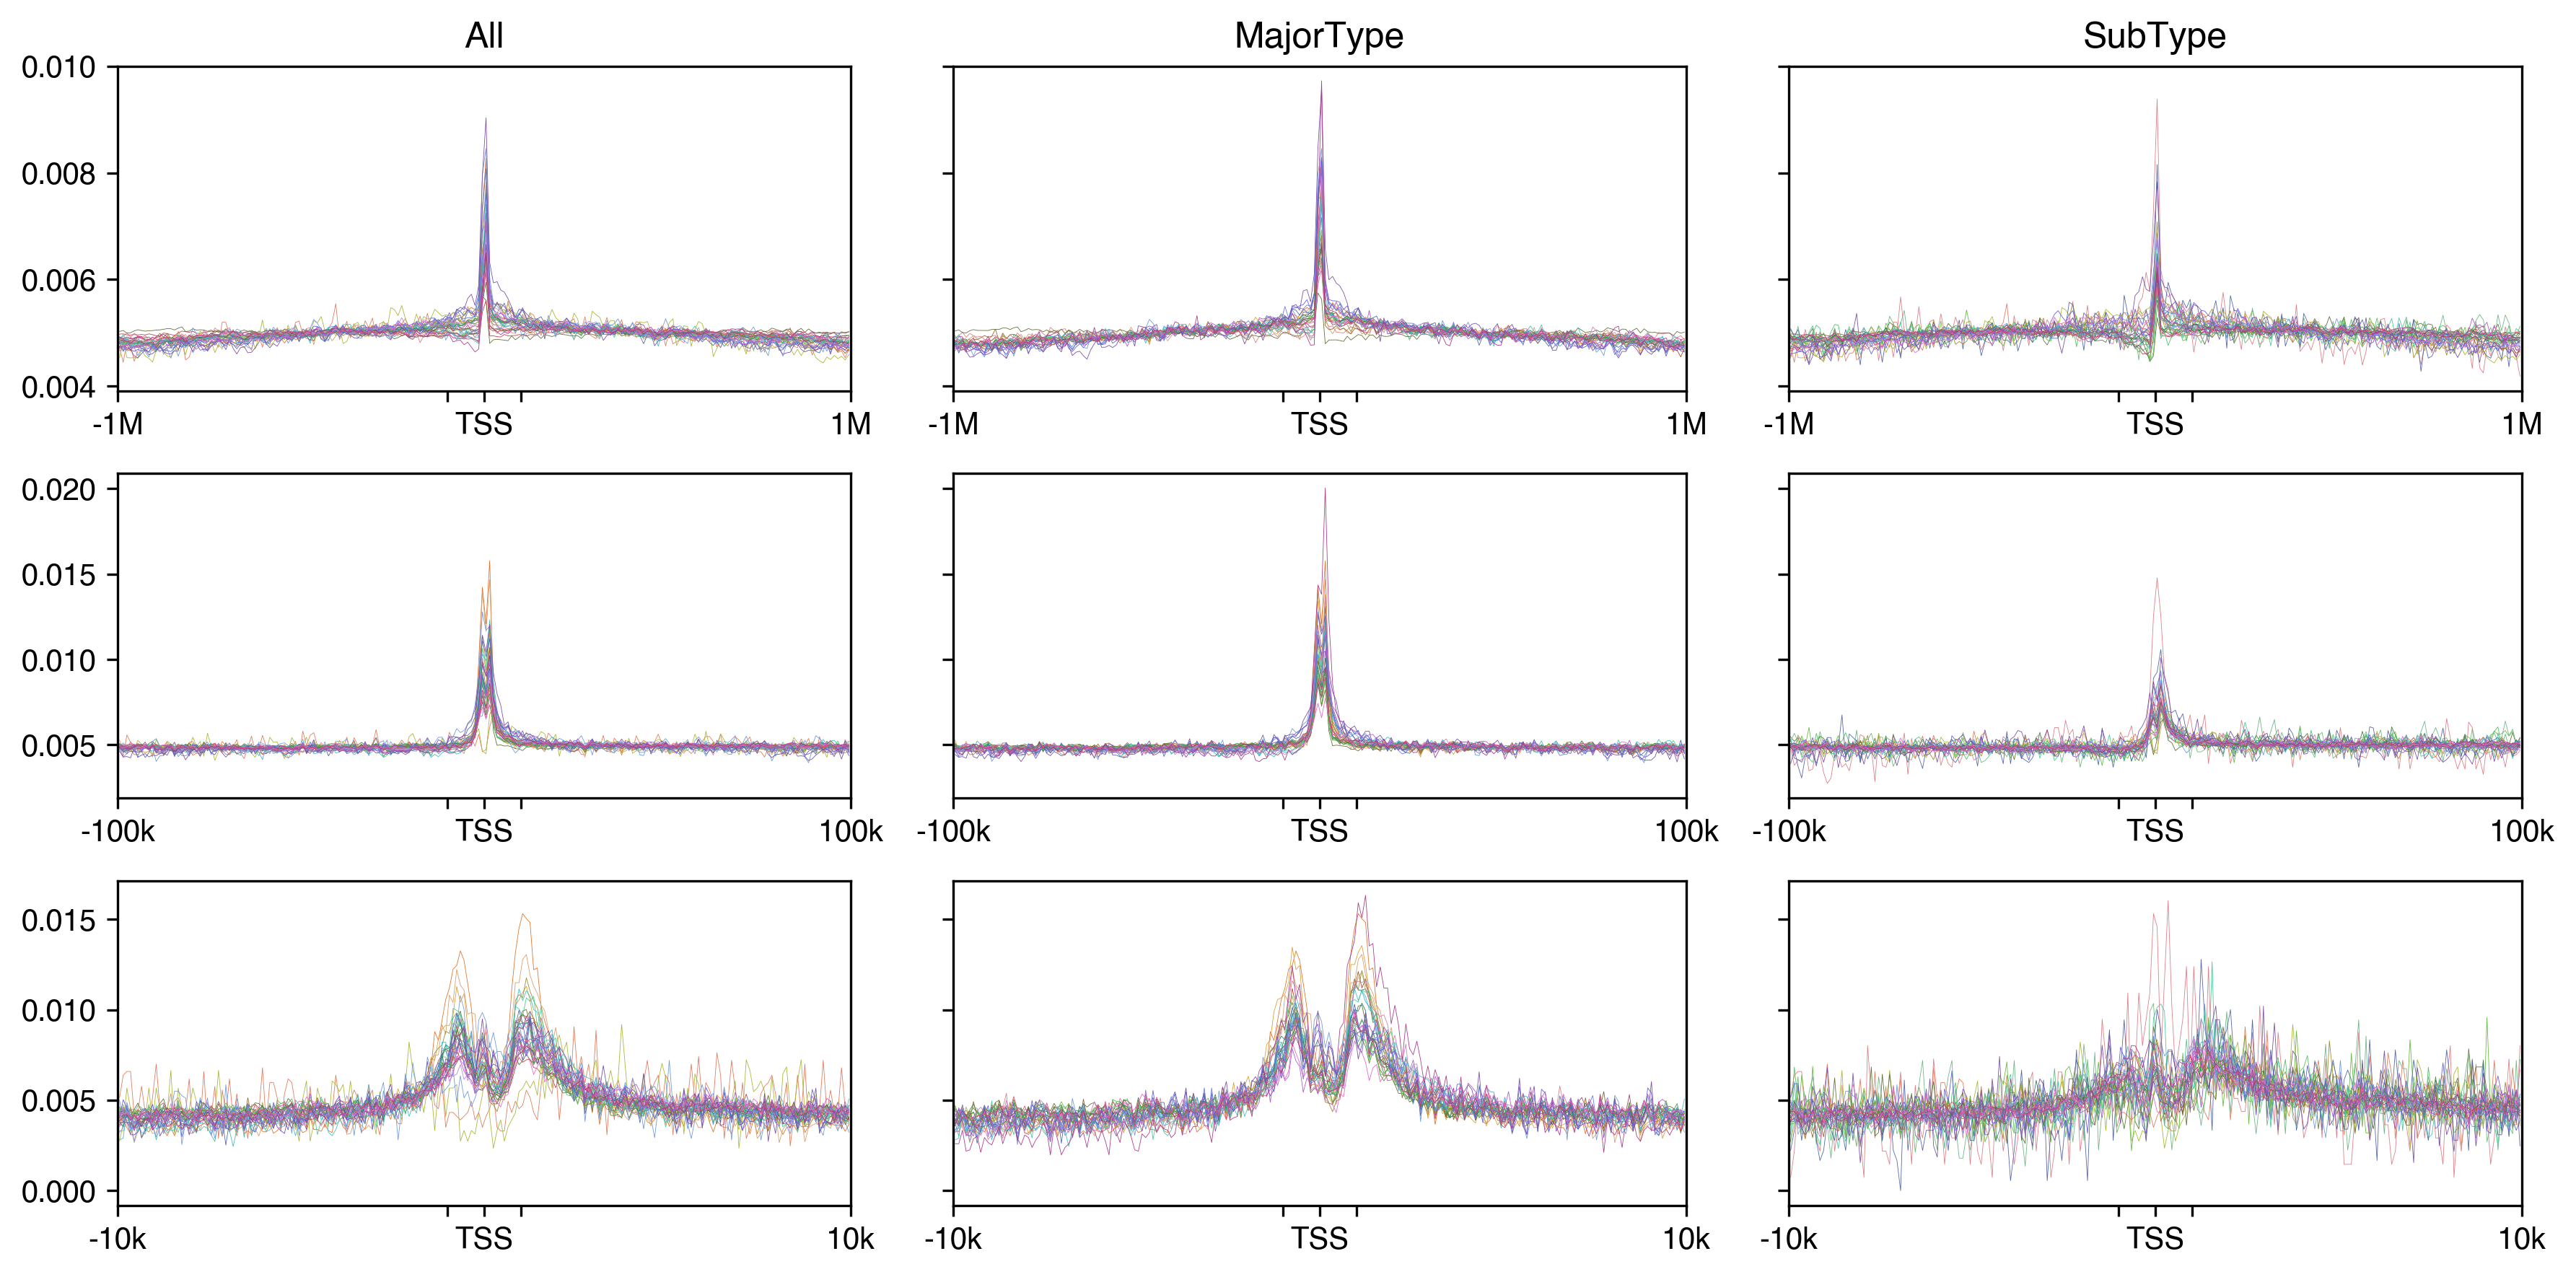

In [ ]:
slop = 100
fig, axes = plt.subplots(3, 3, figsize=(12,6), dpi=300, sharex='row', sharey='row')

for i,res in enumerate([10000, 1000, 100]):
    for j,mode in enumerate(['', 'majortype', 'subtype']):
        s = num2str(slop*res)
        ax = axes[i,j]
        data = pd.read_hdf(f'{outdir}tss_{mode}dmr_dist_{s}.hdf', key='data').fillna(0)
        data = data / data.sum(axis=0)
        for ct in data.columns:
            ax.plot(data.index[:-1]+0.5, data[ct].iloc[:-1], 
                    linewidth=0.2, c=L1_color[ct], label=L1_annot[ct])
        ax.set_xlim([-slop, slop])
        ax.set_xticks([-100, -10, 0, 10, 100])
        s = num2str(slop*res)
        ax.set_xticklabels([f'-{s}', '', 'TSS', '', s])
        ax.set_xlabel('')

for j,mode in enumerate(['All', 'MajorType', 'SubType']):
    axes[0,j].set_title(mode)
    
fig.tight_layout()
fig.savefig('DMR/tss_dist_hcagene.pdf', transparent=True)


In [ ]:
mcds = MCDS.open(f'{indir}merged_allc/subtype1k.mcds', obs_dim='cell', var_dim='chrom1k')
mcds

In [ ]:
bin_df = mcds[['chrom1k_chrom', 'chrom1k_start', 'chrom1k_end']].to_pandas()
bin_df.columns = ['chrom', 'start', 'end']
selb = bin_df['chrom'].isin(chrom_sizes.index)


In [ ]:
print(1)
mcds = mcds.sel({'chrom1k':selb.index[selb]})
global_mc = mcds['chrom1k_da'].sel({'mc_type':'CGN'}).sum(dim='chrom1k').to_pandas()


In [ ]:
global_mc = global_mc.sort_index()
global_mc.to_csv(f'{indir}merged_allc/subtype_globalCG.csv.gz')


In [ ]:
outdir = f'{indir}analysis/DMR/'

In [ ]:
L2_meta = pd.read_csv(f'{indir}subtype_meta.tsv', sep='\t', header=0, index_col=0).fillna('')
L2_meta['L1'] = L2_meta.index.str.split('-').str[0]
L2_meta.loc[L2_meta['L1']=='c7', 'L1'] = 'c35'
L2_meta.loc[L2_meta.index=='c7-b1'] = 'c36'


In [ ]:
mcds = MCDS.open(f'{outdir}subtype_dmr.mcds', obs_dim='subtype', var_dim='DMR')
mcds

In [ ]:
data_all = mcds['DMR_da_frac'].to_pandas()
# data_all.to_hdf(f'{outdir}subtype_dmr.hdf', key='data')
data_all

In [ ]:
selc = ~(L2_meta.loc[data_all.index, 'L1'].isin(['c1','c2','c3','c9','c22','c35']))
data_all = data_all.loc[selc]
print(data_all.shape)

In [ ]:
global_mc = pd.read_csv(f'{indir}merged_allc/subtype_globalCG.csv.gz', index_col=0, header=0)
global_mc['ratio'] = global_mc['mc'] / global_mc['cov']


In [ ]:
hypo = (data_all<(global_mc.loc[data_all.index, ['ratio']].values-0.3))
hyper = (data_all>(global_mc.loc[data_all.index, ['ratio']].values+0.1))
print((hypo.sum(axis=0)>0).sum(), (hyper.sum(axis=0)>0).sum())


In [ ]:
c1, c2 = sns.color_palette('Blues',2)

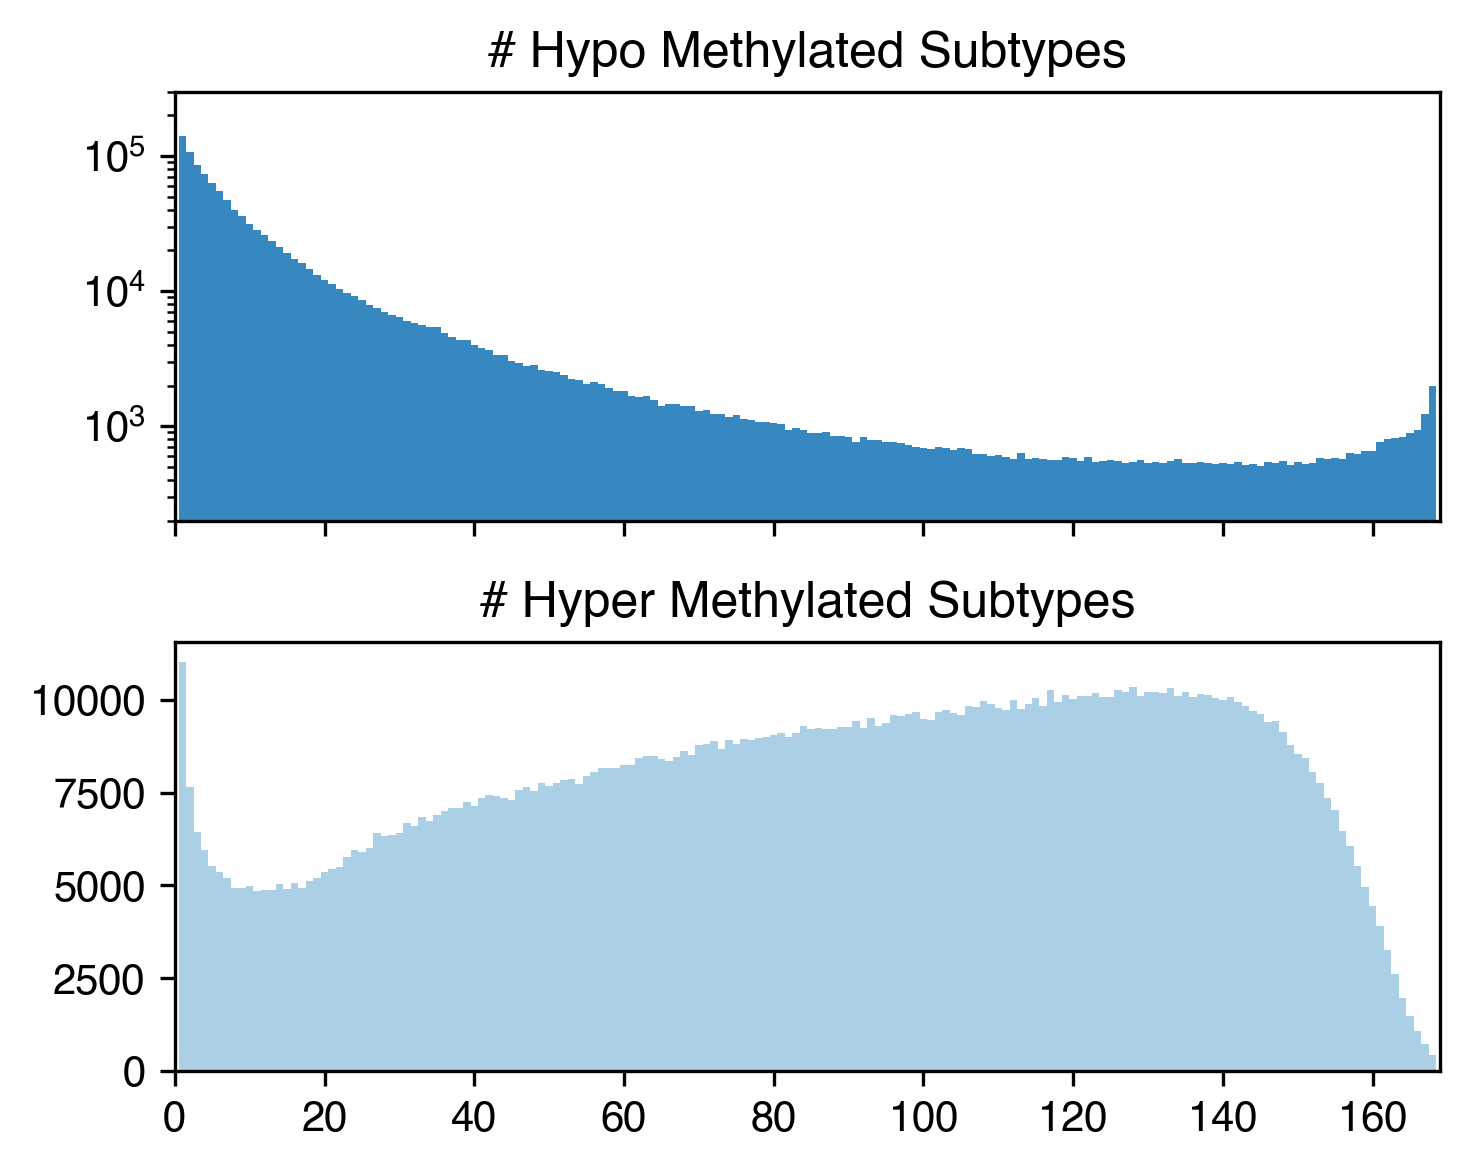

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(5,4), dpi=300, sharex='all')
ax = axes[0]
# sns.histplot(hypo.sum(axis=0), bins=168, binrange=(0,169), ax=ax)
hist = np.histogram(hypo.sum(axis=0), bins=168, range=(1,169))[0]
ax.bar(np.arange(data_all.shape[0])+1, hist, bottom=2e2, width=1, color=c2)
ax.set_yscale('log')
ax.set_ylim([2e2, 3e5])
ax.set_xlim([0, 169])
ax.set_title('# Hypo Methylated Subtypes')
ax = axes[1]
hist = np.histogram(hyper.sum(axis=0), bins=168, range=(1,169))[0]
ax.bar(np.arange(data_all.shape[0])+1, hist, width=1, color=c1)
ax.set_title('# Hyper Methylated Subtypes')
fig.tight_layout()
fig.savefig('DMR/DMR_hypohypercount_subtype.pdf', transparent=True)


In [ ]:
data_all = data_all.fillna(1).T


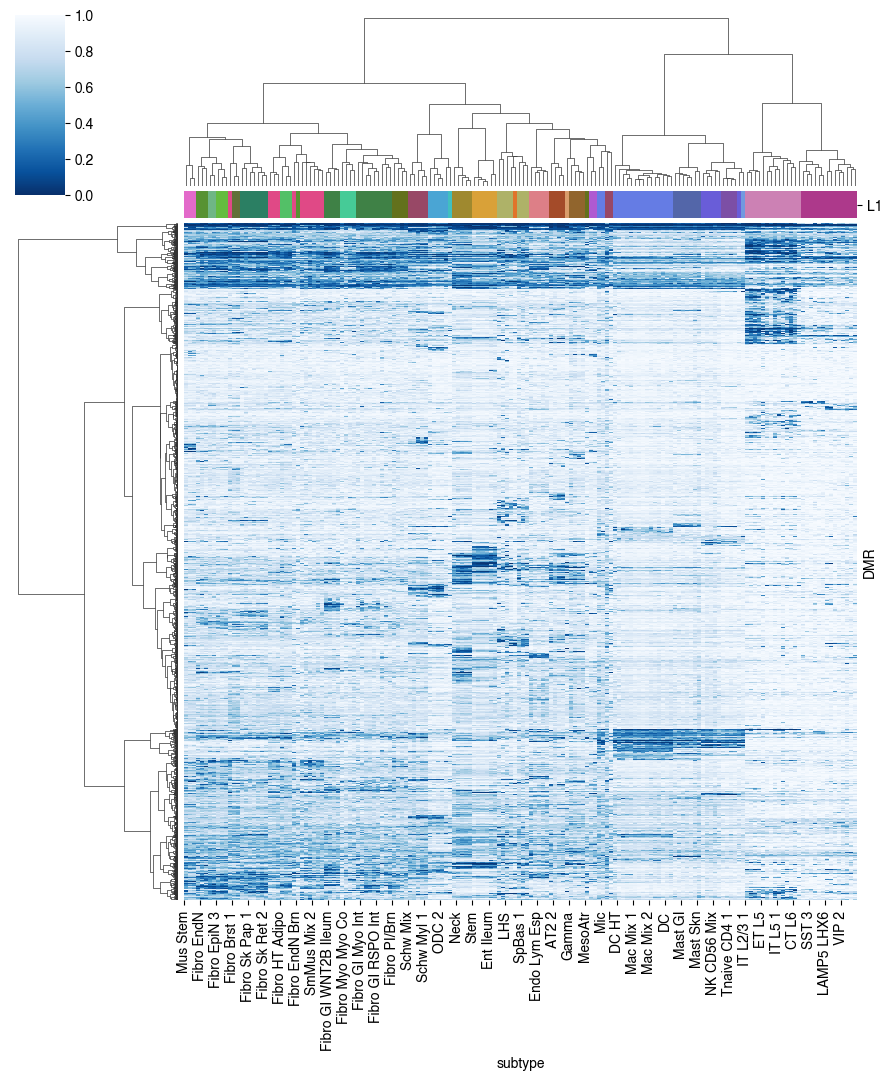

In [ ]:
print(1)
L2_annot = L2_meta['celltype_L2_both_abbr'].to_dict()
xticks = np.arange(0, data_all.shape[1], data_all.shape[1]//40)
np.random.seed(0)
# selc = ~(L2_meta.loc[data_all.columns, 'L1'].isin(['c1','c2','c3','c9','c22','c35']))
selr = np.random.choice(np.arange(data_all.shape[0]), 10000, False)
col_color = L2_meta.loc[data_all.columns, 'L1'].map(L1_color)
cg = sns.clustermap(data_all.iloc[selr], cmap='Blues_r', 
                    metric='euclidean', method='ward', 
                    col_colors=col_color,
                    rasterized=True,
                    vmin=0, vmax=1,
                    )
corder = cg.dendrogram_col.reordered_ind.copy()
ax = cg.ax_heatmap
ax.set_xticks(xticks)
ax.set_xticklabels(data_all.columns.map(L2_annot)[corder][xticks])
ax.set_yticks([])
cg.savefig('DMR/DMR_mCG_heatmap.pdf', transparent=True, dpi=300)


In [ ]:
dmr_all = mcds[['DMR_chrom', 'DMR_start', 'DMR_end']].to_pandas()
dmr_all

In [ ]:
ct = 'c3'
dmr_ds = RegionDS.open(f'{indir}DMR/majortype-subtype/{ct}_dmr', region_dim='dmr')
dmr = dmr_ds[['dmr_chrom', 'dmr_start', 'dmr_end', 'dmr_ndms']].to_pandas()
dmr[['dmr_start', 'dmr_end', 'dmr_ndms']] = dmr[['dmr_start', 'dmr_end', 'dmr_ndms']].astype(int)
seldmr = (dmr['dmr_ndms']>1) & (dmr['dmr_chrom'].isin(chrom_sizes.index))
dmr_ds = dmr_ds.sel({'dmr':dmr.index[seldmr]})
dmr = dmr.loc[seldmr]
data = dmr_ds['dmr_da_frac'].to_pandas().T
seldmr = ((data.max(axis=1) - data.min(axis=1)) > 0.2)
data = data.loc[seldmr].fillna(1)
dmr = dmr.loc[seldmr]

In [ ]:
import pyranges as pr
df1 = dmr[['dmr_chrom', 'dmr_start', 'dmr_end']]
df1.columns = ['Chromosome', 'Start', 'End']
# df1.columns = df1.columns.str.split('_').str[1]
df1 = pr.PyRanges(df1.reset_index())
df2 = dmr_all[['DMR_chrom', 'DMR_start', 'DMR_end']]
df2.columns = ['Chromosome', 'Start', 'End']
# df2.columns = df2.columns.str.split('_').str[1]
df2 = pr.PyRanges(df2.reset_index())

overlap_df = df1.join(df2, suffix='_df2').df.set_index('dmr')
data = data.loc[overlap_df.index]
dmr = dmr.loc[overlap_df.index]

# df1_indices = overlap_df.index.tolist()
# df2_indices = overlap_df['DMR'].tolist()


In [ ]:
import os

for mt in L1_meta.index:
    dmr_file_path = f'{indir}DMR/majortype-subtype/{mt}_dmr/dmr.bed'
    if not os.path.isfile(dmr_file_path):
        continue
    dmr_ds = RegionDS.open(f'{indir}DMR/majortype-subtype/{mt}_dmr', region_dim='dmr')
    dmr = dmr_ds[['dmr_chrom', 'dmr_start', 'dmr_end', 'dmr_ndms']].to_pandas()
    dmr[['dmr_start', 'dmr_end', 'dmr_ndms']] = dmr[['dmr_start', 'dmr_end', 'dmr_ndms']].astype(int)
    seldmr = (dmr['dmr_ndms']>1) & (dmr['dmr_chrom'].isin(chrom_sizes.index))
    dmr_ds = dmr_ds.sel({'dmr':dmr.index[seldmr]})
    dmr = dmr.loc[seldmr]
    dmr_state = dmr_ds['dmr_state'].to_pandas().T
    for ct in dmr_state.columns:
        dmr_tmp = dmr.loc[dmr_state[ct]==-1]
        dmr_tmp[['dmr_chrom', 'dmr_start', 'dmr_end']].to_csv(f'{indir}DMR/majortype-subtype/hypo/{ct}_hypo.bed', sep='\t', header=False, index=False)
    print(mt)
    